### BHSD (Brain Hemorrhage Segmentation Database) Analysis

The [BHSD](https://www.kaggle.com/datasets/stevezeyuzhang/bhsd-dataset/data) is a dataset sourced from the 2019 RSNA ICH Detection Grand Challenge.

It contains 192 volumes with *pixel-level* hemorrhage type information. In the corresponding ground truth masks, pixel value 0 corresponds to background, while 1-5 correspond to EDH, IPH, IVH, SAH, and SDH.

While there is no age information (or any other demographics), it is the largest dataset with pixel level hemorrhage type information that I have found. 

### Dataframe creation

In the below chunk, the data are loaded and the following information is aggregated:
* Hemorrhage type
* Hemorrhage volume
* Mean and median HU within the hemorrhage boundary
* Image dimension information (for calculating volume)
* Number of slices (to calculate vertical spread of hemorrhage)

In [1]:
from pathlib import *
import nibabel as nib
import numpy as np
import pandas as pd
import os
import sys
import skimage as sk
import matplotlib.pyplot as plt

regenerate_spreadsheet = False
save_opt = True
cluster_analysis = True
cluster_threshold = 15 # clusters an area less than this number (in voxels) are excluded

labels = ["bkg", "EDH", "IPH", "IVH", "SAH", "SDH"] # 0, 1, 2, 3, 4, 5

if regenerate_spreadsheet:
    dataset_path = Path('/home/jayse.weaver/RSNA_BHSD/') # can move to public location if necessary
    img_dir = dataset_path / "images"
    truth_dir = dataset_path / "ground_truths"

    row_idx = 0

    # initialize empty dataframe
    df = pd.DataFrame(columns=['Data_ID', 'Type', 'Volume_[mL]', 'Mean_HU', 'Median_HU', 'dx', 'dy', 'dz', 'num_slices', 'z_dist'])

    label_names = sorted(os.listdir(img_dir))
    #label_names = ['ID_69b19057_ID_44d0da38f2.nii.gz']
    #label_names = ['ID_7860208e_ID_f68c193b69.nii.gz']

    for idx, file in enumerate(label_names):
        img = nib.load(img_dir / file)
        [dx, dy, dz] = img.header['pixdim'][1:4]
        image = img.get_fdata()

        mask = nib.load(truth_dir / file).get_fdata()

        for label_idx in range(1, len(labels)): # skip background
            print(labels[label_idx])
            hemorrhage_volume = (len(np.argwhere(mask == label_idx)))*((dx*dy*dz)/1000)
            print(hemorrhage_volume)

            if hemorrhage_volume != 0:
                hemorrhage_mask = np.where(mask == label_idx, 1, 0)

                if cluster_analysis:
                    label_mask, num = sk.measure.label(hemorrhage_mask, return_num=True, connectivity=1)
                    print('number of clusters: ' + str(num))

                    #nib.save(nib.Nifti1Image(np.float32(label_mask), np.eye(4)), 'test_SDH_mask.nii')
                    for cluster_idx in range(1,num+1):
                        cluster = np.where(label_mask == cluster_idx, 1, 0)
                        print('cluster idx: '+str(cluster_idx)+', count: '+str(np.count_nonzero(cluster)))
                        if np.count_nonzero(cluster) > cluster_threshold:
                            num_slices = 0
                            for slice_idx in range(cluster.shape[2]):
                                slice = cluster[:, :, slice_idx]
                                if np.any(slice): # check if hemorrhage
                                    num_slices += 1

                            hemorrhage_volume = (len(np.argwhere(cluster == 1)))*((dx*dy*dz)/1000)

                            z_dist = num_slices * dz

                            # calculate mean and median HU
                            lesion_only = np.multiply(image, cluster)

                            lesion_only[lesion_only < -500] = 0

                            mean_HU = np.mean(lesion_only[np.nonzero(cluster)])
                            median_HU = np.median(lesion_only[np.nonzero(cluster)])

                            df.loc[row_idx] = [str(file), labels[label_idx], hemorrhage_volume, mean_HU, median_HU, dx, dy, dz, num_slices, z_dist]
                            row_idx += 1

                # else:
                #     num_slices = 0
                #     for slice_idx in range(hemorrhage_mask.shape[2]):
                #         slice = hemorrhage_mask[:, :, slice_idx]
                #         if np.any(slice): # check if hemorrhage
                #             num_slices += 1

                #     z_dist = num_slices * dz

                #     # calculate mean and median HU
                #     lesion_only = np.multiply(image, hemorrhage_mask)

                #     lesion_only[lesion_only < -500] = 0

                #     mean_HU = np.mean(lesion_only[np.nonzero(hemorrhage_mask)])
                #     median_HU = np.median(lesion_only[np.nonzero(hemorrhage_mask)])

                #     df.loc[row_idx] = [str(file), labels[label_idx], num, hemorrhage_volume, mean_HU, median_HU, dx, dy, dz, num_slices, z_dist]
                #     row_idx += 1

    print(df)

    if save_opt:
        df.to_csv('RSNA_BHSD_clusters.csv')

else:
    df = pd.read_csv('RSNA_BHSD_clusters.csv')

Type
SAH    1058
IVH     294
IPH     270
SDH     221
EDH      30
Name: count, dtype: int64


<Axes: xlabel='Volume_[mL]', ylabel='Mean_HU'>

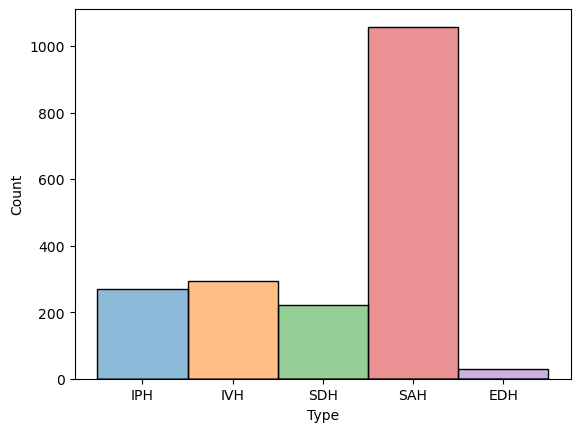

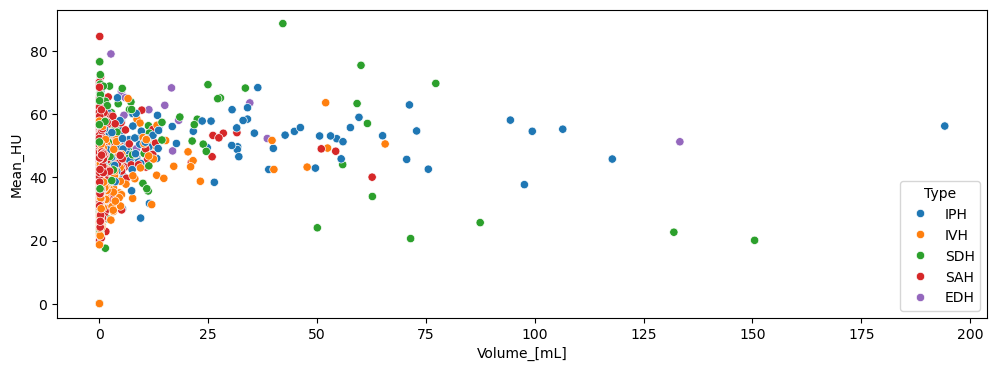

In [2]:
# Let's plot!
import seaborn as sns
import matplotlib.pyplot as plt

print(df['Type'].value_counts())

plt.figure()
sns.histplot(data=df, x="Type", hue="Type", legend=False)

plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x="Volume_[mL]", y="Mean_HU", hue="Type", legend=True)

### The dataset has a nice distribution of IPH, IVH, SDH, and SAD, but an underwhelming number of EDH.

However, this may be expected as SDH is more common than EDH in both severe and mild TBI (https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7912597/)

Next, let's look at all of the volume and HU data together in a joint grid with kernel density estimate plots on the axes:

[10.0,
 100.0,
 0.0,
 150.0,
 10.0,
 100.0,
 0.0,
 150.0,
 10.0,
 100.0,
 0.0,
 150.0,
 10.0,
 100.0,
 0.0,
 150.0,
 10.0,
 100.0,
 0.0,
 150.0]

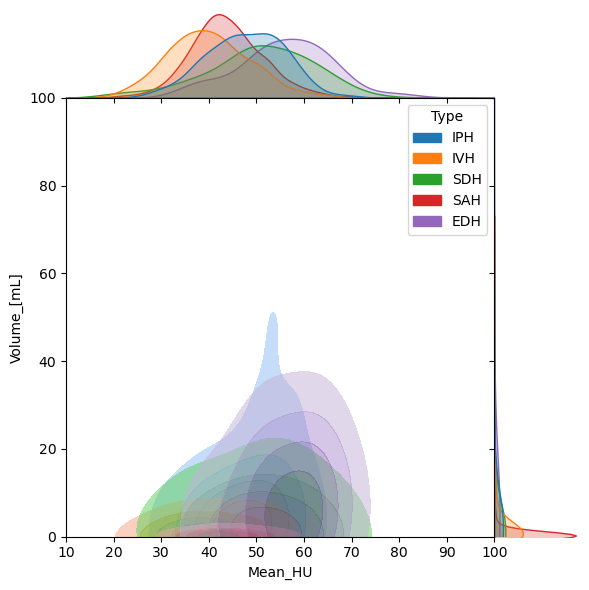

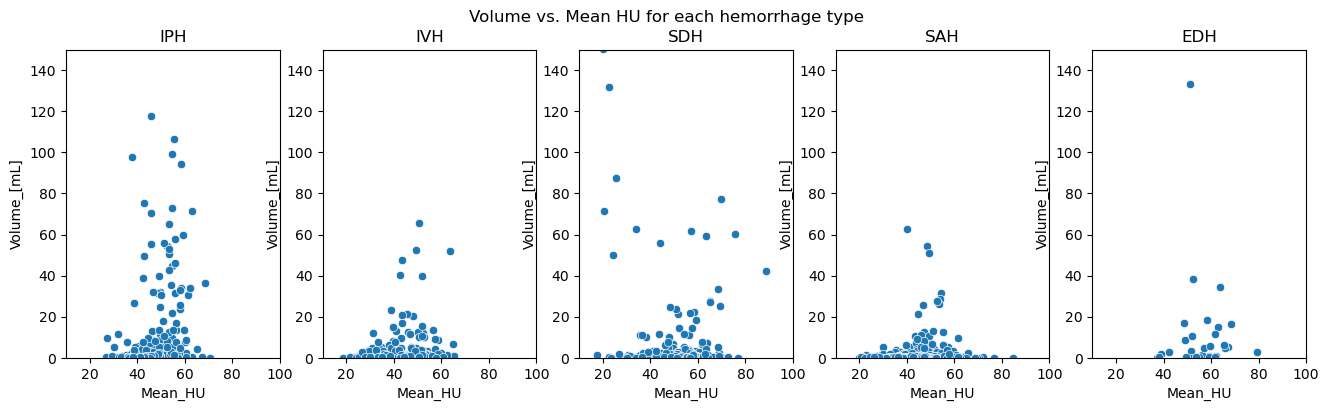

In [3]:
g = sns.JointGrid(data=df, x="Mean_HU", y="Volume_[mL]", hue="Type", space=0, xlim=(10,100), ylim=(0, 100))
g.plot_joint(sns.kdeplot, alpha=0.5, fill=True, multiple='stack', thresh=0.2, levels=5, common_norm=False, clip=(0, 100))
#g.plot_marginals(sns.kdeplot, fill=True, multiple="stack", common_norm="True")
g.plot_marginals(sns.kdeplot, fill=True, common_norm=False)

fig, axes = plt.subplots(1, 5, figsize=(16,4))
fig.suptitle('Volume vs. Mean HU for each hemorrhage type')
axes[0].set_title('IPH')
sns.scatterplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", y="Volume_[mL]")
axes[1].set_title('IVH')
sns.scatterplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", y="Volume_[mL]")
axes[2].set_title('SDH')
sns.scatterplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", y="Volume_[mL]")
axes[3].set_title('SAH')
sns.scatterplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", y="Volume_[mL]")
axes[4].set_title('EDH')
sns.scatterplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", y="Volume_[mL]")
plt.setp(axes, xlim=(10,100), ylim=(0,150))

### If you find the above plot ugly, find the separate kernel density estimate plots below:

<Axes: xlabel='Mean_HU', ylabel='Density'>

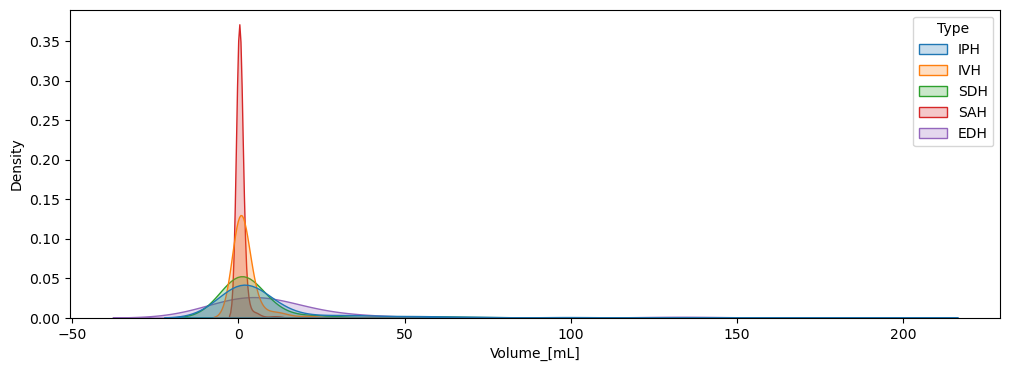

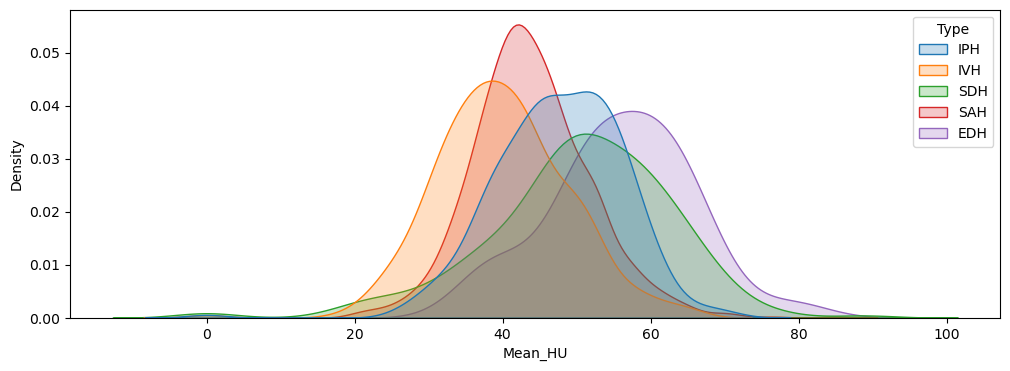

In [4]:

plt.figure(figsize=(12, 4))
sns.kdeplot(data=df, x="Volume_[mL]", hue="Type", legend=True, common_norm=False, fill=True)

plt.figure(figsize=(12, 4))
sns.kdeplot(data=df, x="Mean_HU", hue="Type", legend=True, common_norm=False, fill=True)

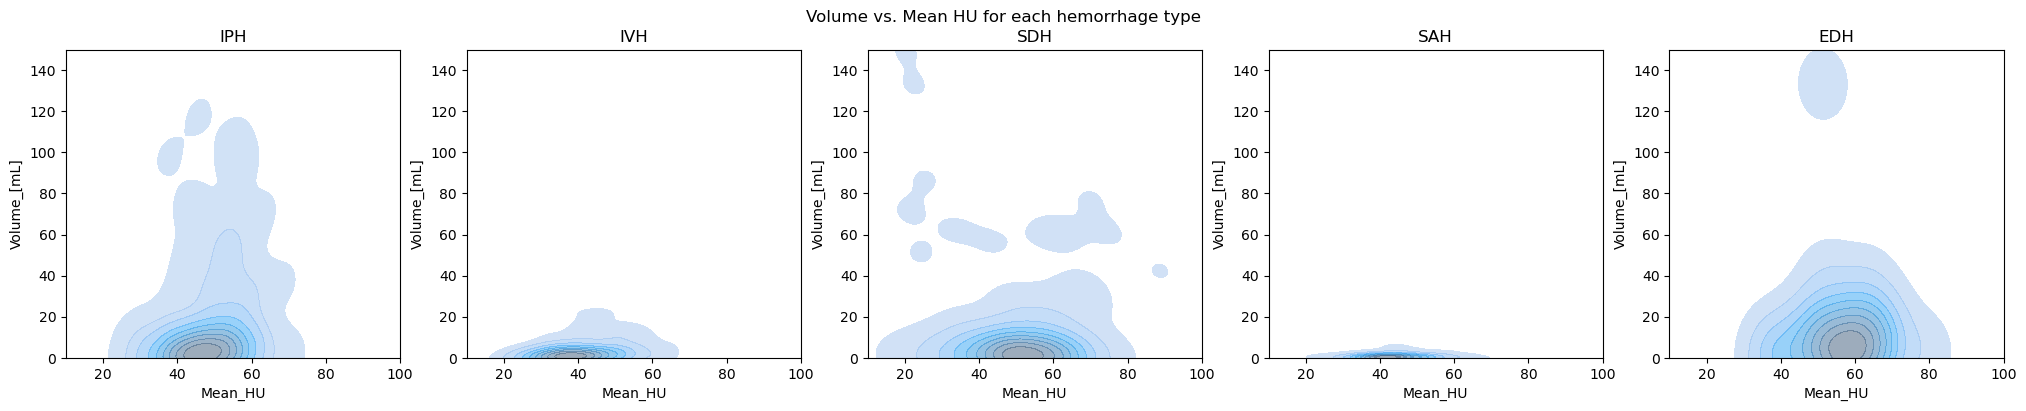

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Volume vs. Mean HU for each hemorrhage type')
axes[0].set_title('IPH')
sns.kdeplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5, thresh=0.02)


axes[1].set_title('IVH')
sns.kdeplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

axes[2].set_title('SDH')
sns.kdeplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

axes[3].set_title('SAH')
sns.kdeplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

axes[4].set_title('EDH')
sns.kdeplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", y="Volume_[mL]", fill=True, alpha=0.5)

_ = plt.setp(axes, xlim=(10,100), ylim=(0,150))

### Next, volume with the number of slices:

<Axes: title={'center': 'EDH'}, xlabel='Volume_[mL]', ylabel='z_dist'>

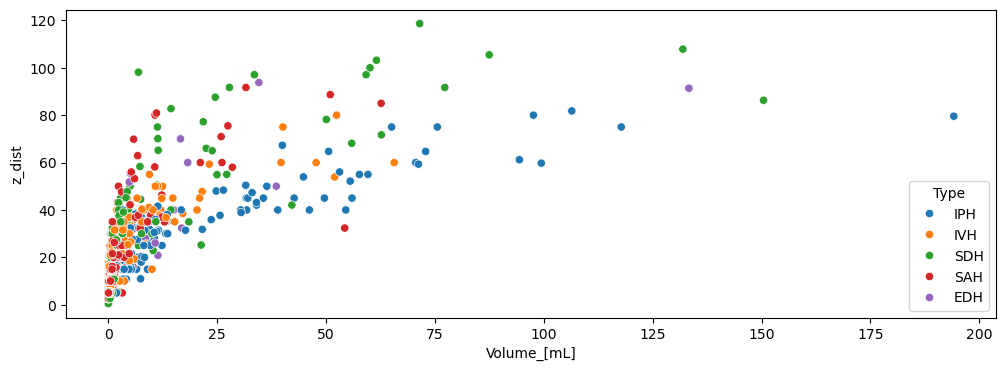

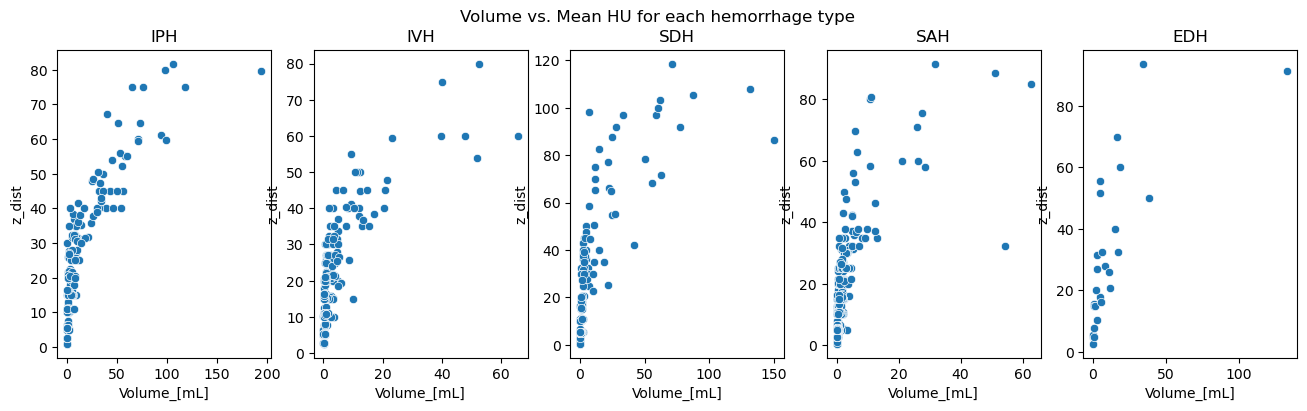

In [6]:
plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x="Volume_[mL]", y="z_dist", hue="Type", legend=True)

fig, axes = plt.subplots(1, 5, figsize=(16,4))
fig.suptitle('Volume vs. Mean HU for each hemorrhage type')
axes[0].set_title('IPH')
sns.scatterplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Volume_[mL]", y="z_dist")
axes[1].set_title('IVH')
sns.scatterplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Volume_[mL]", y="z_dist")
axes[2].set_title('SDH')
sns.scatterplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Volume_[mL]", y="z_dist")
axes[3].set_title('SAH')
sns.scatterplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Volume_[mL]", y="z_dist")
axes[4].set_title('EDH')
sns.scatterplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Volume_[mL]", y="z_dist")

In [7]:
# initialize empty dataframe
log_coeff = pd.DataFrame(columns=['Type', 'c1', 'c2'])
# statistics
for label_idx in range(1, len(labels)):
    subdf = df.loc[df['Type'] == labels[label_idx]]
    fit = np.polyfit(np.log(subdf['Volume_[mL]']), subdf['z_dist'], 1)
    log_coeff.loc[label_idx - 1] = [labels[label_idx], fit[0], fit[1]]

print(log_coeff)

#df.to_csv('RSNA_BHSD.csv')

# grouped = df.groupby('Type')
# print('Mean values of each metric by hemorrhage type:')
# print(grouped.mean('Mean_HU'))
# print(' ')
# print('Median values of each metric by hemorrhage type:')
# print(grouped.median('Mean_HU'))

# df.groupby('Type')[['Mean_HU','Volume_[mL]']].corr()

  Type         c1         c2
0  EDH  10.230661  19.094043
1  IPH   6.925315  17.315256
2  IVH   6.657283  20.492770
3  SAH   5.382939  18.237267
4  SDH  10.380327  24.480868


Mean values of each metric by hemorrhage type:
       Unnamed: 0  Volume_[mL]    Mean_HU  Median_HU        dx        dy  \
Type                                                                       
EDH    695.333333    11.514054  55.972682   56.40000  0.483082  0.483082   
IPH    902.411111    10.248063  47.541462   48.02963  0.485064  0.485064   
SDH   1011.529412     6.581266  50.312719   49.98190  0.488297  0.488297   

            dz  num_slices     z_dist  
Type                                   
EDH   4.782126    6.033333  28.725955  
IPH   4.946042    3.874074  19.489942  
SDH   4.853763    4.253394  20.632532  
 
Median values of each metric by hemorrhage type:
      Unnamed: 0  Volume_[mL]    Mean_HU  Median_HU        dx        dy  \
Type                                                                      
EDH        664.5     3.933083  56.658936       56.5  0.488281  0.488281   
IPH        883.5     1.243125  47.729807       48.0  0.488281  0.488281   
SDH       1058.0     

Mean_HU  Volume_[mL]
Type                                   
EDH  Mean_HU      1.000000    -0.020432
     Volume_[mL] -0.020432     1.000000
IPH  Mean_HU      1.000000     0.222881
     Volume_[mL]  0.222881     1.000000
SDH  Mean_HU      1.000000    -0.132198
     Volume_[mL] -0.132198     1.000000

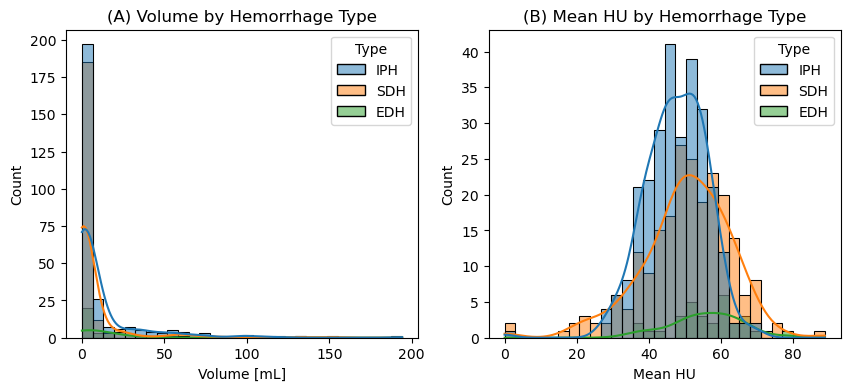

In [9]:
mask = df['Type'] == 'SAH'
df = df[~mask]
mask = df['Type'] == 'IVH'
df = df[~mask]


fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(ax=axes[0], data=df, x='Volume_[mL]', hue='Type', bins=30, kde=True)
axes[0].set_title('(A) Volume by Hemorrhage Type')
axes[0].set_xlabel('Volume [mL]')
sns.histplot(ax=axes[1], data=df, x='Mean_HU', hue='Type', bins=30, kde=True, legend=True)
axes[1].set_title('(B) Mean HU by Hemorrhage Type')
axes[1].set_xlabel('Mean HU')

grouped = df.groupby('Type')
print('Mean values of each metric by hemorrhage type:')
print(grouped.mean('Mean_HU'))
print(' ')
print('Median values of each metric by hemorrhage type:')
print(grouped.median('Mean_HU'))

df.groupby('Type')[['Mean_HU','Volume_[mL]']].corr()